In [1]:
#import networkx as nx
import sys
import os
from tqdm import tqdm

notebookname =  'NB_250521_StatefulBandit'
current_directory_os = os.getcwd()

# Add related modules to path
sys.path.append(current_directory_os+'/'+notebookname)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from matplotlib.colors import LinearSegmentedColormap
import time

from action_scheduler import Schedule
from ResistorNetwork import makeNetwork
from experiment import Experiment
from TaskMaker import makeDataset


## Create Network

#### Constructed PLATTICE network, G_MOS edges, NN = 16 , NE = 32


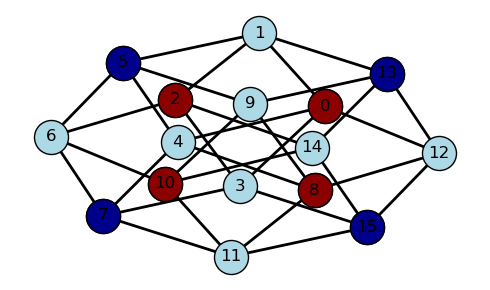

In [3]:
""" choose conduction (edge) functionality """
conduct_func, directed = 'G_MOS',False #'G_MOS_NORM', False # 'G_DIO' # 'G_DIG' # 

""" select size and architecture of network """
network_type,network_spec = 'PLATTICE',[4,4]

network = makeNetwork(network_type, network_spec,conduct_func, directed = directed)
network.params= network.params*0+2.0 + np.random.randn(np.size(network.params))*.05 # initialize
#network.params= network.params*0+50.0 + np.random.randn(np.size(network.params))*5 # initialize

""" select IO nodes """
a = np.sum(network_spec[:2])
b = np.sum(network_spec[:-1])
INODES, ONODES = [0,2,8,10], [5,7,13,15]
IONODES = np.array(INODES+ONODES).astype(int)

print("#### Constructed",network_type, "network,",conduct_func, "edges, NN =", network.num_nodes, ", NE =", len(network.node_to))
network.display_graph(directed = directed,nodegroups=[INODES,ONODES],figsize=(5,3))

### Define Task (Q Learning)

['2', '0', '3', '1']


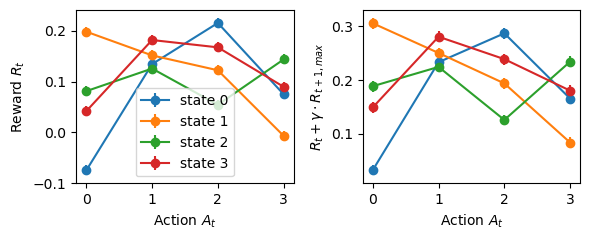

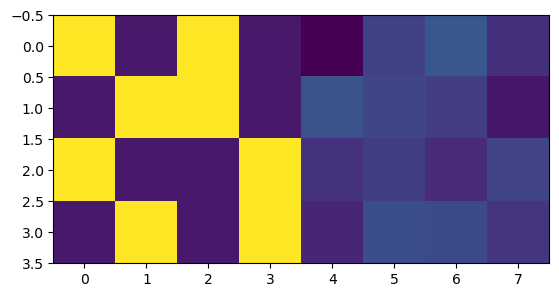

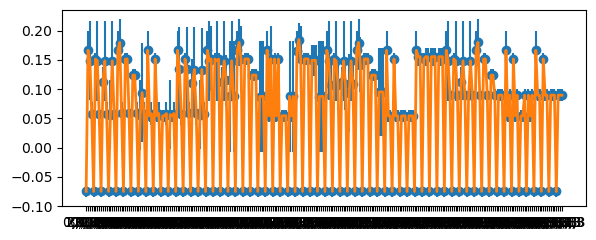

In [4]:
np.random.seed(100) 

DIF = 0 # use for differential outputs
_NOISE_SCALE = .01
_N_ARMS = len(ONODES)//(1+DIF) # 4
_N_STATES = 4#len(ONODES)# 4
GAM = .5 # discount factor for future states
EPS = .05
EPM = 0
    
q_true = np.random.randn(_N_STATES,_N_ARMS)*0.1+.1  # true value of the actions

TRA = _N_STATES
TST = 0
INP = len(INODES)

DATA = np.zeros((TRA+TST,np.size(IONODES)))+ np.mean(q_true)

GND = 0.0
VPL = 1

DATA[:,0] = [VPL, GND, VPL,GND]
DATA[:,1] = [GND, VPL,GND,VPL]
DATA[:,2] = [VPL,VPL, GND, GND] 
DATA[:,3] = [GND,GND,VPL,VPL]
# fill rewards later

QReward = lambda state, action: q_true[state, action] + _NOISE_SCALE * np.random.randn(1)[0]  # obtain reward
QState = lambda state, action: (action) % _N_STATES # obtain next state


get_Q_future = lambda state,action: q_true[state, action] + GAM*np.max(q_true[QState(state,action),:])
q_target = np.zeros_like(q_true)
for state in range(_N_STATES):
    for action in range(_N_ARMS):
       # print(state,action)
        q_target[state,action] = get_Q_future(state,action)


fig, axs = plt.subplots(1,2,figsize=(6,2.5))

for plot in range(2):
    if plot==0:
        mat = q_true
        ylim = r'Reward $R_t$'
    elif plot==1:
        mat = q_target
        ylim = r'$R_t + \gamma \cdot R_{t+1,max}$'

    for state in range(_N_STATES):
        axs[plot].errorbar(x = np.arange(_N_ARMS),y=mat[state,:],yerr=_NOISE_SCALE,fmt='-o',label='state '+str(state))
    #axs[plot].set_ylim([GND,VPL])
    axs[plot].set_xlabel(r'Action $A_t$')
    axs[plot].set_ylabel(ylim);

axs[0].legend()

DATA[:,len(INODES)::(1+DIF)] = q_true # assign labels as true reward matrix

plt.tight_layout()

plt.figure()
plt.imshow(DATA);


maxavgreward = -10000
strats = []
rewards = []
rewards_std=[]
testingsteps = 10000

#iterate through all possible strategies
for idx in range(_N_ARMS**_N_STATES):
    rewardbatch = []
    strategy = [(idx//(_N_ARMS**i))%(_N_ARMS) for i in range(_N_STATES)]
    state = 0

    for t in range(testingsteps):
        if np.random.rand(1)[0]<EPM:
            action = np.random.randint(_N_ARMS)
        else:
            action = strategy[state]
        rewardbatch+= [QReward(state,action)]
        state = QState(state,action)

    strats.append([str(i) for i in strategy])
    rewards.append(np.mean(rewardbatch))
    rewards_std.append(np.std(rewardbatch))


fig = plt.figure(figsize=(6,2.5))
x = np.arange(len(rewards))
plt.errorbar(x,rewards,yerr=rewards_std,fmt='o')
plt.plot(x,rewards,'-',lw=2,zorder=10)
plt.xticks(ticks=x, labels=[','.join(i) for i in strats]);
plt.tight_layout()

print(strats[np.argmax(rewards)])


### Specify Hyperparamters and Schedule

In [5]:
""" Select steps, approx (upper lim) meas count, batching rate """
STP = 100000
MES = 300 # logarithmically spaced
minMESdelta = 10
BTH = 50

""" define other parameters """
params = {
        "ALF":.3, # learning rate
        "ETA":.1, # nudge factor
        "OVC":None, # overclamping
        "NOR":0, # batch normalization
        "DIF":DIF, # differential outputs
        "DGC":.1, # dG (gradient) clipping
        "CLA":1, # number of classes (1 for non-classification)
        "TRA":TRA, # number of training datapoints (also implies # test w/ DATA)
        "INP":INP, # number of inputs (also implies # outputs w/ DATA or IONODE)
        "TDS":0, # training data selection (0 for random, < 0 to indicate cycling with period abs(n))
        "GMN":1,#0.5, # minimum for learning parameters
        "GMX":5.5,#99.5, # maximum for learning parameters
        "FLP":1.0, # multiply this to learning steps -- fixes resistance vs capacitance
        "LOS":2, # 2 indicates using Q reinforcement learning
        "EPS":EPS, # for QRL, starting fraction that a random action (datapoint) is taken (trained)      
        "EPM":EPM, # for QRL, min fraction that a random action (datapoint) is taken (trained)      
        "MXP": 1, # MULT exponent (for overclamping) 0 means linear cost, 1 is quadratic (normal)  
        "GAM": GAM, # for LOS==2 (Q Learning) with env state, discount factor for future estimates
        "UDE": 0#2, #update exponent  (0 is standard for conductance)
}

# GMN,GMX Values for X9C303S8I digital potentiometer (shorturl.at/mEbBy)

""" Set Schedule for training/measuring """
meas_steps = np.unique((np.logspace(-.01,np.log10(STP-1),MES)).astype(int))
idx = 0
while idx<len(meas_steps)-1:
    if meas_steps[idx+1]-meas_steps[idx] < minMESdelta:
        meas_steps = np.delete(meas_steps,idx+1)
    else:
        idx +=1
        
MES = len(meas_steps) # corrected for dups

index_lists = {
    1: meas_steps,  # measurement steps
}
actions = [
   # ['INIT', 0],        # only on step 0
    ['STOREPARAM', 0],  
    ['MEASURE', 0],
    ['TRAIN', -1],      # every step
    ['BATCH', -BTH],     # every BTH steps
    ['STOREPARAM', 1],  # on specified measurement steps
    ['MEASURE', 1],     # on specified measurement steps
]

sched = Schedule(STP, actions, index_lists)


# summarize what's been specified
for key,value in params.items():
    print(key+": "+str(value)+" || ",end='')
print("\n")

sched.display()

ALF: 0.3 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 4 || INP: 4 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.05 || EPM: 0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 100000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  STOREPARAM, MEASURE [list 1]


### Compile Experiment and run!

Training: 100%|████████████████████████▉| 99999/100000 [02:35<00:00, 641.52it/s]


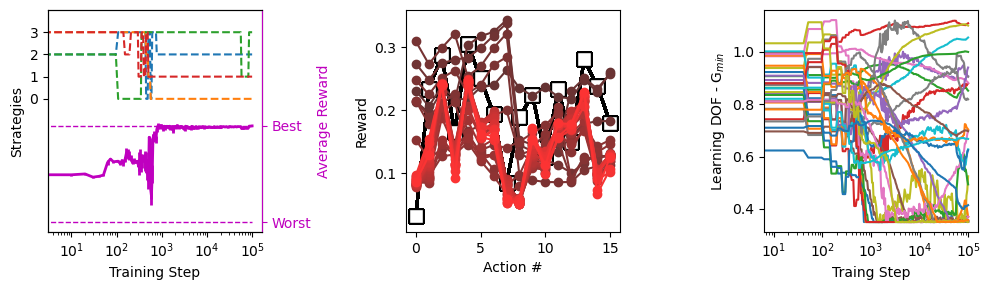

Training: 100%|████████████████████████▉| 99999/100000 [02:32<00:00, 657.73it/s]


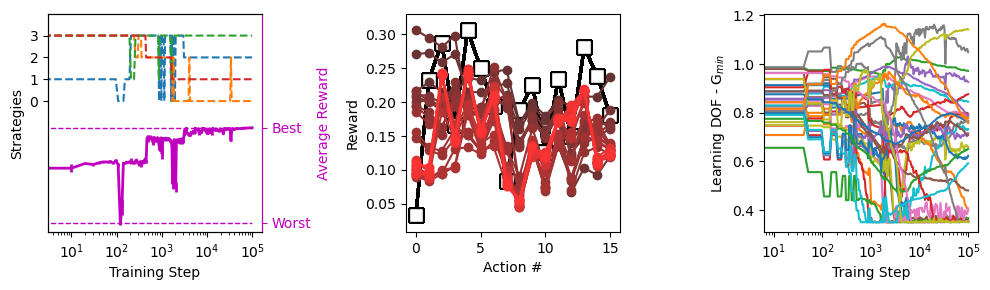

Training: 100%|████████████████████████▉| 99999/100000 [02:26<00:00, 680.71it/s]


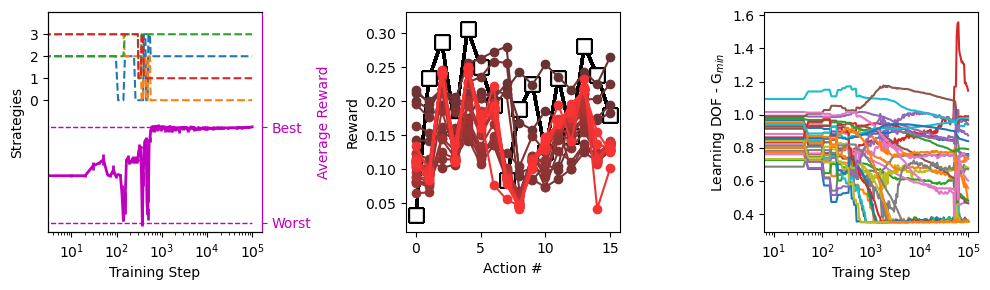

Training: 100%|████████████████████████▉| 99999/100000 [02:26<00:00, 681.99it/s]


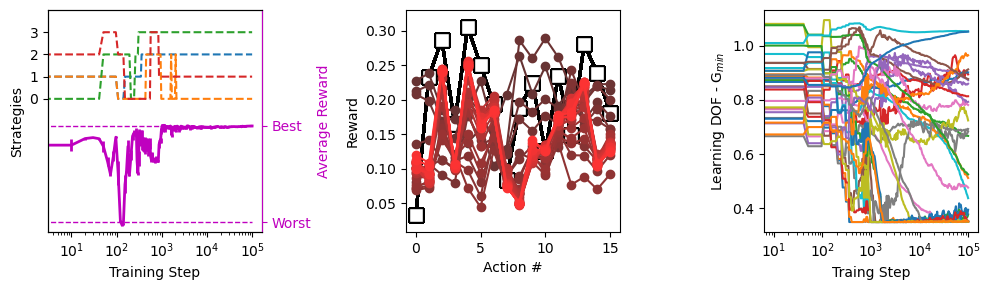

Training: 100%|████████████████████████▉| 99999/100000 [02:28<00:00, 674.09it/s]


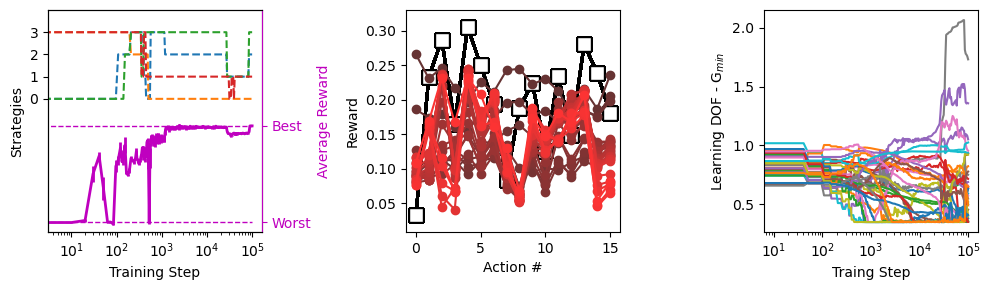

Training: 100%|████████████████████████▉| 99999/100000 [02:25<00:00, 687.51it/s]


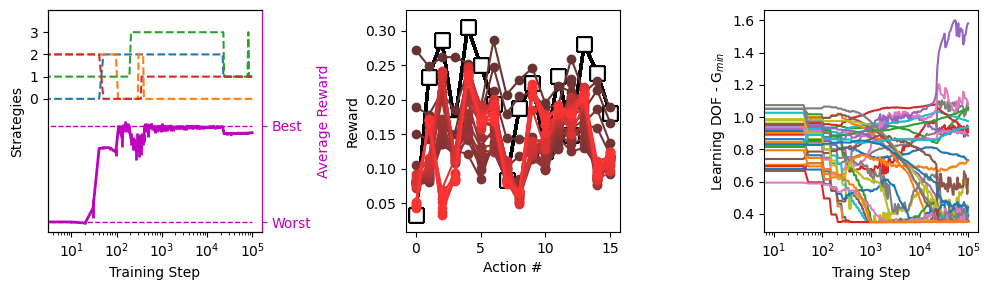

Training: 100%|████████████████████████▉| 99999/100000 [02:28<00:00, 674.54it/s]


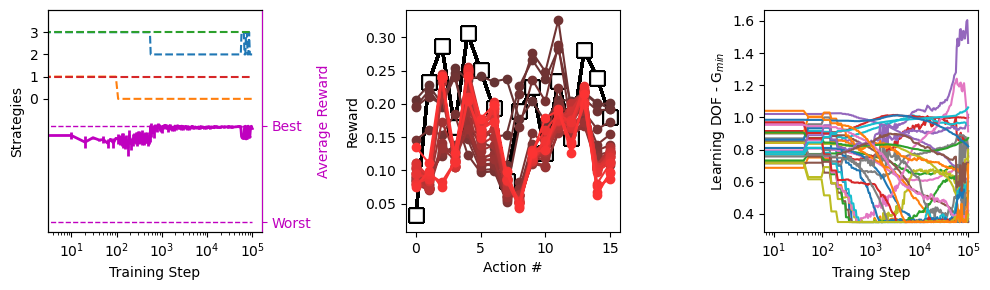

Training: 100%|████████████████████████▉| 99999/100000 [02:30<00:00, 666.62it/s]


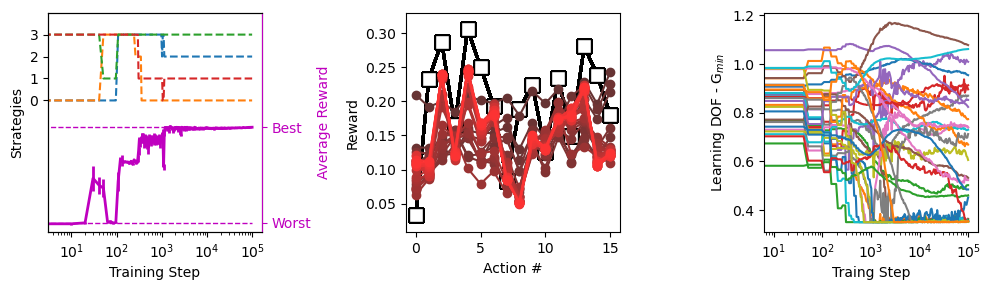

Training: 100%|████████████████████████▉| 99999/100000 [02:32<00:00, 656.35it/s]


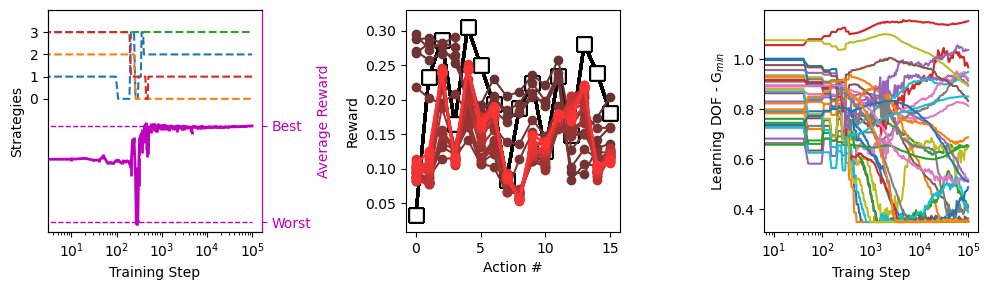

Training: 100%|████████████████████████▉| 99999/100000 [02:31<00:00, 659.18it/s]


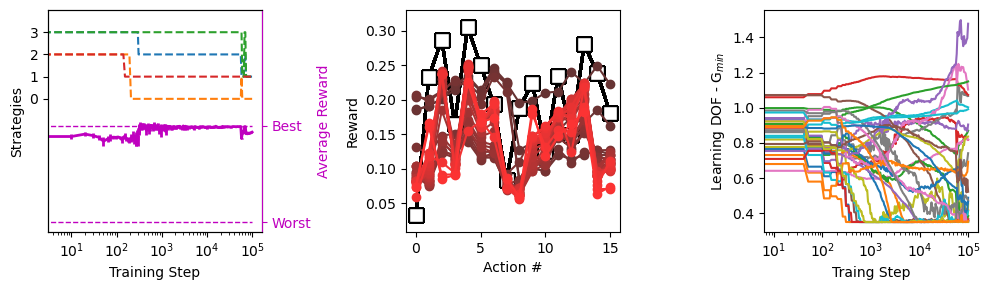

In [6]:
inits =[]
EXPs = []
for _ in range(10):
    init_random = np.random.randn(np.size(network.params))*.1
    inits.append(init_random)
    for _ in range(1):
        EXP = Experiment(params, sched, DATA, IONODES, network)
        EXP.QReward = QReward
        EXP.QState = QState
        EXP.beta1 = .6
        EXP.beta2 = .999
        EXP.epsilon = 1e-3
        EXP.network.params= network.params*0+1.5 + init_random
        
        EXP.run()
        
        fig, axs = plt.subplots(1,3,figsize=(10,3))
        #plt.plot(EXP.stored_params)
        
        for edgeidx in range(EXP.NE):
            axs[2].semilogx(EXP.stored_param_steps,[i[edgeidx]-.65 for i in EXP.stored_params])
        axs[2].set_xlabel('Traing Step')
        axs[2].set_ylabel(r'Learning DOF - G$_{min}$')
        
        MES = len(EXP.stored_state_steps)
        
        stored_states = np.array(EXP.stored_states)
        skipnum=6
        inputs = np.arange(EXP.OUT*EXP.TRA//(1+EXP.DIF))
        labels = np.copy(EXP.DATA[:,EXP.INP:])
        
        errors = []
        strategies = []
        
        for measidx in range(MES):
            outputnums = EXP.IONODE[EXP.INP:]
            if EXP.DIF:
                outputs = -stored_states[measidx,:,outputnums[::2]]+stored_states[measidx,:,outputnums[1::2]]
            else:
                outputs = stored_states[measidx,:,outputnums]
        
            outputs = np.transpose(outputs)
        
            strat = []
            for a in range(_N_STATES):
                strat.append(np.argmax(outputs[a,:]))
            strategies.append(strat)
            
            if measidx % skipnum == 0:
                axs[1].plot(inputs,outputs.flatten(),'o-',c=[.6*measidx/MES+.4,.2,.2])
        
            errors.append(np.mean((outputs.flatten()-q_target.flatten())**2))
            #errors.append(np.mean(EXP.stored_loss[measidx]))
            #print(np.mean(EXP.stored_loss[measidx])-np.mean((outputs-labels)**2))
            
            axs[1].errorbar(x = inputs,y=q_target.flatten(),yerr=_NOISE_SCALE,linestyle='-', fmt='ks',ms=10,mfc='w',lw=2,zorder=-100)
        
            
        axs[1].set_xlabel('Action #')
        axs[1].set_ylabel('Reward')
        
        
        # loss should be true - predicted. take norm differently to weight high/low values
        
        
        #axs[0].loglog(EXP.stored_state_steps,errors,'k-',lw=2)
        for n in range(_N_STATES):
            axs[0].semilogx(EXP.stored_state_steps,[i[n] for i in strategies],'--')
        
        axs[0].set_yticks(ticks=np.arange(_N_ARMS))
        
        axs[0].set_xlabel('Training Step')
        axs[0].set_ylabel('Strategies')
        axs[0].set_ylim([-_N_ARMS-2,_N_ARMS])
        
        
        
        if EXP.LOS==2:
            axs2 = axs[0].twinx()
            othercolor = 'm'
            exprewards = EXP.stored_reward
            rewarderrs = [i/np.sqrt(j) for i,j in zip(EXP.stored_reward_std,EXP.stored_reward_count)]
            axs2.errorbar(EXP.stored_state_steps,exprewards,fmt=othercolor+'-',lw=2,yerr=rewarderrs)
            axs2.set_ylabel('Average Reward')
            axs2.spines['right'].set_color(othercolor)
            axs2.tick_params(axis='y', colors=othercolor)
            axs2.yaxis.label.set_color(othercolor)
            axs2.semilogx(EXP.stored_state_steps,[np.max(rewards) for i in EXP.stored_state_steps],othercolor+'--',lw=1)
            axs2.semilogx(EXP.stored_state_steps,[np.min(rewards) for i in EXP.stored_state_steps],othercolor+'--',lw=1)
            rng = np.max(rewards)-np.min(rewards)
            axs2.set_ylim([np.min(rewards)-rng*.1,np.min(rewards)+2.2*rng])
            axs2.set_yticks(ticks = [np.min(rewards), np.max(rewards)],labels=['Worst','Best'])
           # axs2.set_ylim([np.min(rewards)-rng*.5, np.max(rewards)+rng*.5])

        EXPs.append(EXP)
        plt.tight_layout()
        plt.show()
        #fig.savefig(notebookname+'/17_Training_plattice_MOSFET_4x4Bandit_onehot.pdf', format='pdf', bbox_inches='tight', dpi=300);

In [7]:

strategies = []
for EXP in EXPs:
    measidx = -1;
    outputnums = EXP.IONODE[EXP.INP:]
    stored_states = np.array(EXP.stored_states)

    if EXP.DIF:
        outputs = -stored_states[measidx,:,outputnums[::2]]+stored_states[measidx,:,outputnums[1::2]]
    else:
        outputs = stored_states[measidx,:,outputnums]
    
    outputs = np.transpose(outputs)
    
    strat = []
    for a in range(_N_STATES):
        strat.append(int(np.argmax(outputs[a,:])))
    strategies.append(strat)

    
            

finalscores = [i.stored_reward[-1] for i in EXPs]
beststrat = [int(i) for i in strats[np.argmax(rewards)]]

print([(i-np.max(rewards))/(np.max(rewards)-np.min(rewards)) for i in finalscores])
print([i==beststrat for i in strategies])
#print(beststrat)
#print(strategies)
print(np.min(finalscores)/np.max(rewards) , 'to', np.max(finalscores)/np.max(rewards), 'percentile')
print('top',sum([i>=np.min(finalscores) for i in rewards]), 'to', len([i for i in rewards if i>=np.max(finalscores)]))
print('out of',len(rewards))

[np.float64(-1.7132995926665005e-05), np.float64(-0.0013621661177032555), np.float64(0.0013585655805672808), np.float64(-0.0007900777238821201), np.float64(0.0002989401286218653), np.float64(-0.07094472788293099), np.float64(-0.025534618000320364), np.float64(-0.0007423062905269511), np.float64(-0.00039390317327323373), np.float64(-0.06502234968368219)]
[True, True, True, True, True, False, True, True, True, False]
0.9001746466220115 to 1.0019116189914927 percentile
top 16 to 0
out of 256


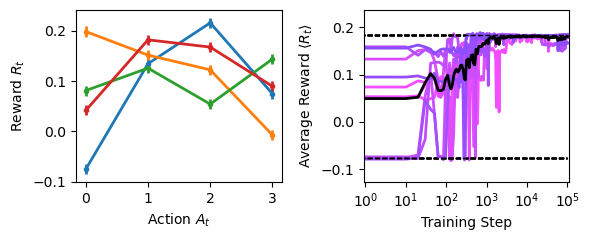

In [8]:
fig, axs = plt.subplots(1,2,figsize=(6,2.5))
count = 0
rew = 0

for expidx,EXP in enumerate(EXPs):
    
    MES = len(EXP.stored_state_steps)
    
    stored_states = np.array(EXP.stored_states)
    inputs = np.arange(EXP.OUT*EXP.TRA)
    labels = np.copy(EXP.DATA[:,EXP.INP:])
    
    errors = []
    strategies = []
    
    mat = q_true
    ylim = r'Reward $R_t$'

    if expidx==0:
        for state in range(_N_STATES):
            axs[0].errorbar(x = np.arange(_N_ARMS),y=mat[state,:],yerr=_NOISE_SCALE,lw=2,ms=3,fmt='-o',label='state '+str(state))
            axs[0].set_xlabel(r'Action $A_t$')
            axs[0].set_ylabel(ylim);
    
    othercolor = [1-.05*expidx,.3,1]
    exprewards = EXP.stored_reward
    rew += np.array(exprewards)
    count+=1
    rewarderrs = [i/np.sqrt(j) for i,j in zip(EXP.stored_reward_std,EXP.stored_reward_count)]

    axs[1].plot(EXP.stored_state_steps,exprewards,'-',c=othercolor,lw=2)#,yerr=rewarderrs)
    axs[1].set_ylabel(r'Average Reward $\langle R_t \rangle$')
    axs[1].set_xlabel('Training Step')

    axs[1].semilogx(EXP.stored_state_steps,[np.max(rewards) for i in EXP.stored_state_steps],'k'+'--',lw=1)
    axs[1].semilogx(EXP.stored_state_steps,[np.min(rewards) for i in EXP.stored_state_steps],'k'+'--',lw=1)
    rng = np.max(rewards)-np.min(rewards)
    axs[1].set_ylim([np.min(rewards)-rng*.2,np.min(rewards)+1.2*rng])
    axs[1].set_xlim([1/1.1,1.1*10**5])
    axs[1].set_xticks(ticks = np.logspace(0,5,6))
 
    plt.tight_layout()
   
axs[1].plot(EXP.stored_state_steps,rew/count,'k-',lw=2,zorder=1000)
fig.savefig('Fig3.pdf', format='pdf', bbox_inches='tight', dpi=300);